# 05 — Final model: synthesis of the configurations and in-depth evaluation

This notebook gathers:
1. the **best model of each configuration** (P, L, channels, horizon);
2. the **final model** (architecture selected in configurations 1 to 3, operational day-ahead horizon = 24 h);
3. its comparison with the baselines (persistence, 7-day mean, **multi-output Ridge**, univariate PatchTST) with Diebold-Mariano tests;
4. observed/predicted plots, residuals and the seed **rosary**;
5. robustness (noise curve), stability (30-day rolling, monthly RMSE), **TimeSeriesSplit cross-validation**;
6. the "capacity index" ablation;
7. explainability (occlusion, integrated gradients, cross-channel attention);
8. efficiency, the final score and saving `models/best_patchtst.pt`.

> **Why is the final horizon not chosen by the score?** Comparing horizons means comparing different tasks:
> the 1 h error is mechanically lower than the 24 h error. The horizon is set by the use case:
> day-ahead dispatch planning. Configuration 4 describes how performance evolves with the horizon.

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analysis as an, json, torch, dataclasses
from nb05_final import cfg_from_name, final_model, validation_seed, load_model, STEPS

## 1. Best model of each configuration

In [2]:
ds = m.build_dataset()
selection = json.loads((m.CACHE_DIR / "selection.json").read_text())
rows = []
for step in STEPS:
    r = m.evaluate_configuration(cfg_from_name(selection[step]), ds)
    t = m.comparison_table([r]).iloc[0]
    rows.append(dict(step=step, selected=selection[step], RMSE=t.RMSE, RMSE_std=t.RMSE_std, nRMSE=t.nRMSE,
                     R2=t.R2, noise_degradation=t.noise_degradation, drift_7d=t.drift_7d, inference_ms=t.inference_ms,
                     score=t.score))
best = pd.DataFrame(rows); best.to_csv(m.TABLES_DIR / "best_per_configuration.csv", index=False)
best.round(4)

,step,selected,RMSE,RMSE_std,nRMSE,R2,noise_degradation,drift_7d,inference_ms,score
0,config1_patch,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
1,config2_history,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
2,config3_channels,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
3,config4_horizon,PatchTST-CAX_P12_L168_H12,8.6091,0.0554,0.1942,0.9762,0.0052,0.5761,2.6194,8.1922


## 2. Final model and comparison with the baselines

In [3]:
cfg = final_model()
res = m.evaluate_configuration(cfg, ds)
preds, y_true, orig = an.load_predictions(cfg.name())
print("Final model:", cfg.name(), "|", cfg)
ridge = pd.read_csv(m.CACHE_DIR / "final" / "ridge.csv")
y_ridge = np.load(m.CACHE_DIR / "final" / "ridge_pred.npy")
res_ci = m.evaluate_configuration(dataclasses.replace(cfg, channel_mode="CI", known_future=False, physical_gate=False), ds)
refs = {"Persistence D-1": m.daily_persistence(ds, orig, cfg.H), "7-day mean": m.seven_day_mean(ds, orig, cfg.H),
        "Multi-output Ridge": y_ridge}
rows = [dict(model=k, **m.metrics(y_true, v)) for k, v in refs.items()]
for r in [res_ci, res]:
    s = r["summary"]
    rows.append(dict(model=r["name"] + " (mean 5 seeds)", RMSE=s["RMSE_mean"], MAE=s["MAE_mean"], nRMSE=s["nRMSE_mean"],
                     R2=s["R2_mean"], MBE=s["MBE_mean"]))
comparison = pd.DataFrame(rows); comparison.to_csv(m.TABLES_DIR / "baseline_comparison.csv", index=False)
comparison.round(4)

Final model: PatchTST-CAX_P12_L168_H24 | PatchTSTConfig(P=12, L=168, H=24, channel_mode='CA', known_future=True, physical_gate=False, d_model=64, n_heads=4, n_layers=2, d_ff=128, dropout=0.1, lr=0.001, batch_size=128, max_epochs=25, patience=4, train_step=1, epoch_fraction=0.2, val_step=6)


,model,RMSE,MAE,nRMSE,R2,MBE
0,Persistence D-1,10.3923,4.9667,0.2348,0.9653,0.0030
1,7-day mean,10.8215,5.3064,0.2445,0.9624,-0.0260
2,Multi-output Ridge,9.1966,4.8673,0.2078,0.9729,-0.6942
3,PatchTST-CI_P12_L168_H24 (mean 5 seeds),9.4676,5.4778,0.2139,0.9712,0.4551
4,PatchTST-CAX_P12_L168_H24 (mean 5 seeds),9.0158,5.2086,0.2037,0.9739,-0.0050


In [4]:
# Diebold-Mariano tests (representative seed of the final model against each baseline)
g_rep = an.representative_seed(res)
e_mod = preds[m.SEEDS.index(g_rep)] - y_true
dm = []
for k, v in refs.items():
    stat, p = m.diebold_mariano_test(e_mod, v - y_true, h=cfg.H)
    dm.append(dict(baseline=k, DM=stat, p_value=p, skill_score=1 - np.sqrt((e_mod**2).mean()) / np.sqrt(((v - y_true)**2).mean())))
pd.DataFrame(dm).round(4)

,baseline,DM,p_value,skill_score
0,Persistence D-1,-2.9661,0.0030,0.1314
1,7-day mean,-3.0762,0.0021,0.1659
2,Multi-output Ridge,-0.7995,0.4240,0.0185


## 3. Seed rosary, observed vs predicted series and residuals

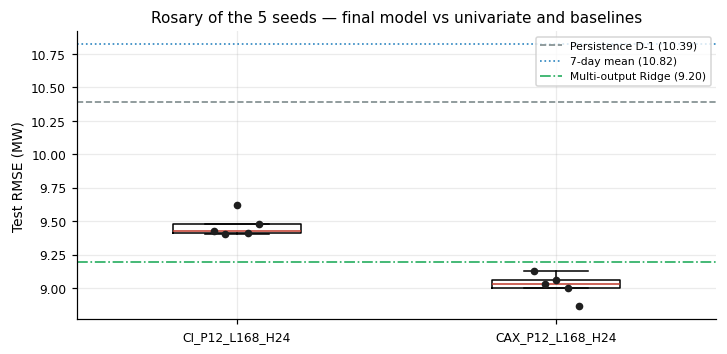

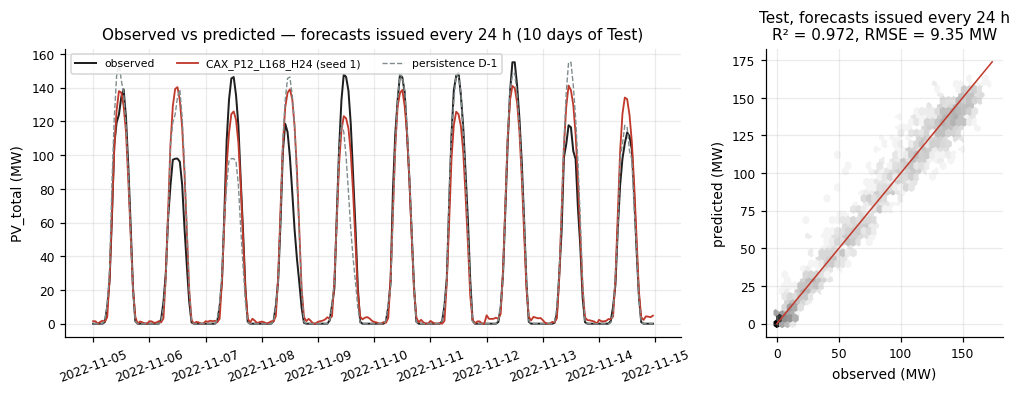

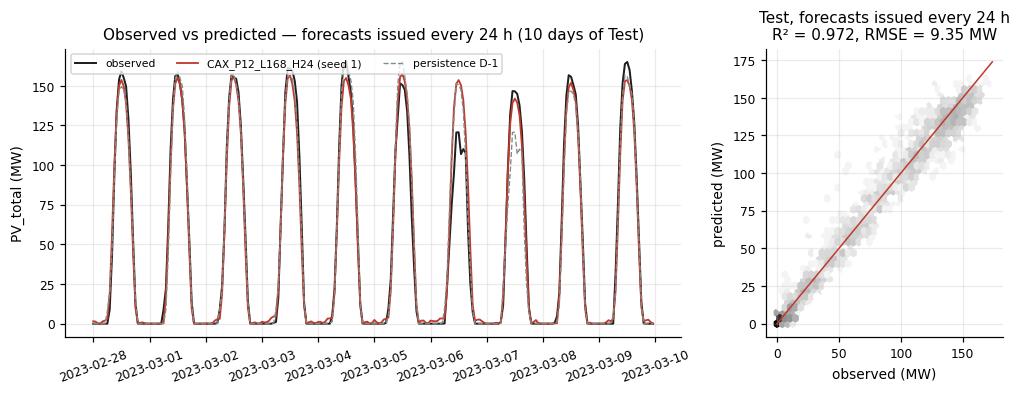

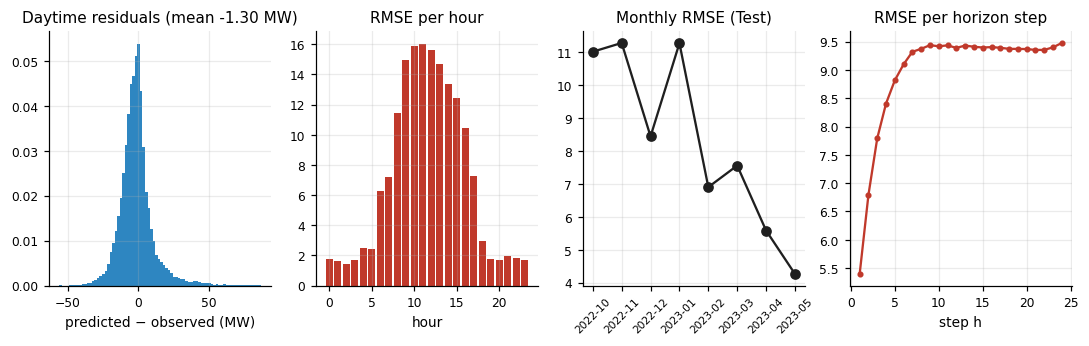

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
groups = {an.label(r["name"]): [g["RMSE"] for g in r["per_seed"]] for r in [res_ci, res]}
ax.boxplot(list(groups.values()), widths=0.4, showfliers=False, medianprops=dict(color=fs.COLORS["model"]))
for i, d in enumerate(groups.values()):
    ax.scatter(np.full(len(d), i + 1) + np.linspace(-0.07, 0.07, len(d)), d, s=16, color=fs.COLORS["observed"], zorder=3)
styles = {"Persistence D-1": ("--", fs.COLORS["persistence"]), "7-day mean": (":", fs.COLORS["mean"]),
          "Multi-output Ridge": ("-.", "#27ae60")}
for k, v in refs.items():
    r = m.metrics(y_true, v)["RMSE"]; ax.axhline(r, ls=styles[k][0], color=styles[k][1], lw=1.1, label=f"{k} ({r:.2f})")
ax.set_xticks(range(1, len(groups) + 1), list(groups.keys())); ax.set_ylabel("Test RMSE (MW)")
ax.legend(fontsize=7, loc="upper right"); ax.set_title("Rosary of the 5 seeds — final model vs univariate and baselines")
fs.save(fig, "fig_final_rosary")
an.fig_observed_vs_predicted(res, ds, "fig_final_observed_predicted")
an.fig_observed_vs_predicted(res, ds, "fig_final_observed_predicted_dry_season", days=10, start_day=150)
an.fig_residuals(res, ds, "fig_final_residuals")

## 4. Robustness: degradation as a function of the noise level on the exogenous channels

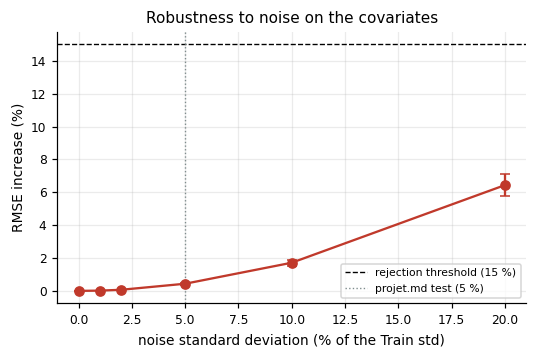

,mean,std
level,,
0.00,0.000,0.000
0.01,0.015,0.004
0.02,0.067,0.009
0.05,0.435,0.048
0.10,1.714,0.180
0.20,6.437,0.662


In [6]:
noise = pd.read_csv(m.CACHE_DIR / "final" / "noise.csv")
b = noise.groupby("level").degradation.agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.errorbar(100 * b.index, 100 * b["mean"], yerr=100 * b["std"], marker="o", color=fs.COLORS["model"], capsize=3)
ax.axhline(15, color="k", ls="--", lw=0.9, label="rejection threshold (15 %)")
ax.axvline(5, color=fs.COLORS["persistence"], ls=":", lw=0.9, label="projet.md test (5 %)")
ax.set_xlabel("noise standard deviation (% of the Train std)"); ax.set_ylabel("RMSE increase (%)"); ax.legend(fontsize=7)
ax.set_title("Robustness to noise on the covariates")
fs.save(fig, "fig_final_noise")
(100 * b).round(3)

## 5. Long-term stability: 30-day rolling and monthly RMSE over the whole Test set

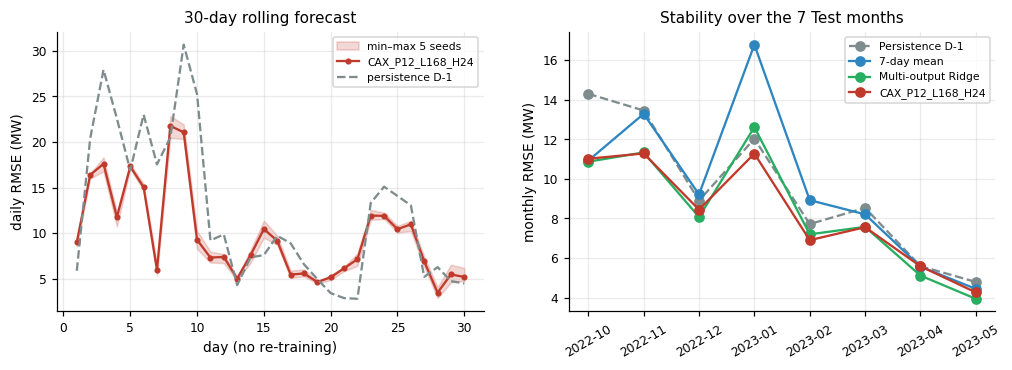

,Persistence D-1,7-day mean,Multi-output Ridge,CAX_P12_L168_H24
timestamp,,,,
2022-10,14.301,10.924,10.869,11.020
2022-11,13.456,13.288,11.337,11.286
2022-12,8.903,9.214,8.072,8.447
2023-01,12.030,16.783,12.614,11.279
2023-02,7.717,8.925,7.198,6.904
2023-03,8.535,8.208,7.576,7.559
2023-04,5.592,5.568,5.114,5.585
2023-05,4.791,4.440,3.942,4.264


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
rd = np.array([g["daily_rmse"] for g in res["per_seed"]])
k30 = orig < ds.i_test + 24 * 30
rd_p = m.daily_rmse(y_true[k30], refs["Persistence D-1"][k30], orig[k30], ds)
days = np.arange(1, rd.shape[1] + 1)
ax[0].fill_between(days, rd.min(0), rd.max(0), color=fs.COLORS["model"], alpha=0.2, label="min–max 5 seeds")
ax[0].plot(days, rd.mean(0), color=fs.COLORS["model"], marker=".", label=an.label(cfg.name()))
ax[0].plot(days, rd_p.values, color=fs.COLORS["persistence"], ls="--", label="persistence D-1")
ax[0].set_xlabel("day (no re-training)"); ax[0].set_ylabel("daily RMSE (MW)"); ax[0].legend(fontsize=7)
ax[0].set_title("30-day rolling forecast")
mm = {k: an.monthly_rmse(y_true, v, orig, ds) for k, v in refs.items()}
mm[an.label(cfg.name())] = an.monthly_rmse(y_true, preds[m.SEEDS.index(g_rep)], orig, ds)
colors = {"Persistence D-1": fs.COLORS["persistence"], "7-day mean": fs.COLORS["mean"],
          "Multi-output Ridge": "#27ae60", an.label(cfg.name()): fs.COLORS["model"]}
for k, s in mm.items():
    ax[1].plot(range(len(s)), s.values, marker="o", label=k, color=colors[k],
               ls="--" if k == "Persistence D-1" else "-")
ax[1].set_xticks(range(len(s)), s.index, rotation=30); ax[1].set_ylabel("monthly RMSE (MW)"); ax[1].legend(fontsize=7)
ax[1].set_title("Stability over the 7 Test months")
fs.save(fig, "fig_final_stability")
pd.DataFrame(mm).round(3)

## 6. Temporal cross-validation (TimeSeriesSplit, 5 expanding-window folds)

For each fold, the normalisation is **re-fitted** on the Train part of the fold (R2); 15 % of the training window
is used for early stopping; the next block is the test. The folds cover 2019–2023: this checks that performance
does not depend on a particular period.

In [8]:
cv = pd.read_csv(m.CACHE_DIR / "final" / "cross_validation.csv")
cv.to_csv(m.TABLES_DIR / "cross_validation.csv", index=False)
display(cv.round(4))
print(f"Mean gain vs persistence: {100*cv.gain_vs_persistence.mean():+.1f} % ± {100*cv.gain_vs_persistence.std():.1f} %")

,fold,train,test,RMSE,nRMSE,R2,RMSE_persistence,gain_vs_persistence,epochs
0,1,2019-01 → 2019-08,2019-09-23 → 2020-06-13,7.6732,0.2469,0.9645,7.8612,0.0239,20
1,2,2019-01 → 2020-03,2020-06-14 → 2021-03-05,10.1804,0.3341,0.9345,11.6726,0.1278,15
2,3,2019-01 → 2020-11,2021-03-06 → 2021-11-25,12.0865,0.2670,0.9540,14.4161,0.1616,25
3,4,2019-01 → 2021-06,2021-11-26 → 2022-08-17,10.8585,0.2458,0.9617,13.3488,0.1866,22
4,5,2019-01 → 2022-01,2022-08-18 → 2023-05-09,9.9412,0.2274,0.9675,12.0269,0.1734,25


Mean gain vs persistence: +13.5 % ± 6.6 %


## 7. Ablation: causal "capacity index"

Variant: the model learns k = PV_total / C(t), where C(t) is the 99 % quantile of the daily maxima of the **previous**
30 days (apparent capacity, updated causally after each commissioning). The forecast is converted back to MW by
multiplying by C(t). Same configuration, 5 seeds.

In [9]:
kc = pd.read_csv(m.CACHE_DIR / "final" / "capacity_index.csv")
s = res["summary"]
pd.DataFrame([dict(variant="RevIN only (final model)", RMSE=s["RMSE_mean"], RMSE_std=s["RMSE_std"], drift_7d=s["drift_7d_mean"]),
              dict(variant="Capacity index + RevIN", RMSE=kc.RMSE.mean(), RMSE_std=kc.RMSE.std(), drift_7d=kc.drift_7d.mean())]).round(4)

,variant,RMSE,RMSE_std,drift_7d
0,RevIN only (final model),9.0158,0.0974,0.5839
1,Capacity index + RevIN,9.0995,0.1651,0.5808


## 8. Explainability

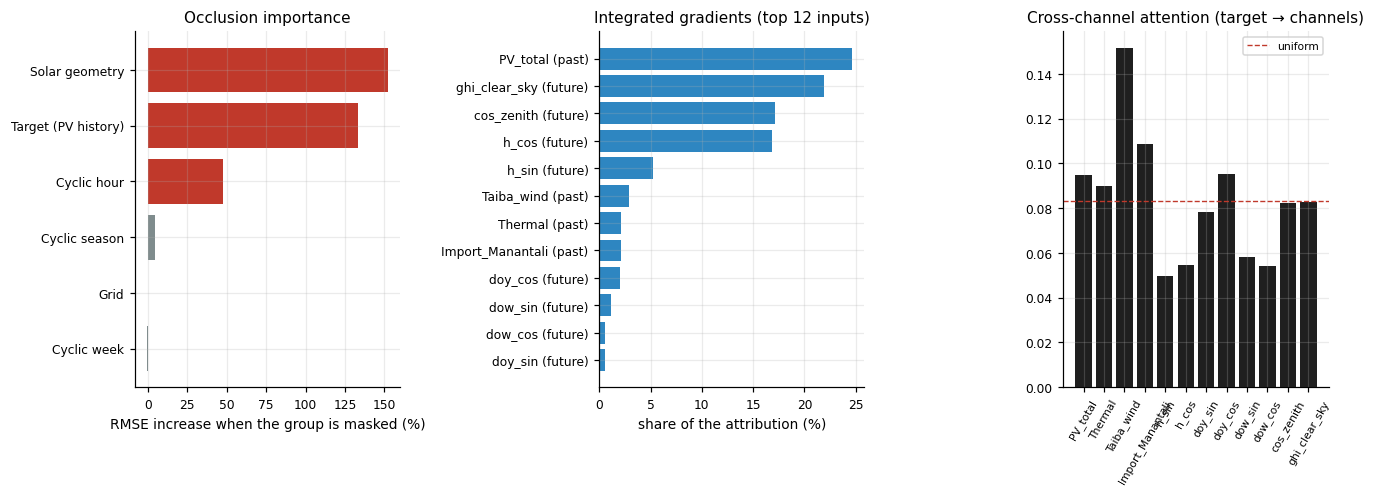

,group,RMSE,RMSE_increase
0,Target (PV history),21.0900,1.3359
1,Grid,9.0384,0.0011
2,Cyclic hour,13.3303,0.4765
3,Cyclic season,9.4231,0.0437
4,Cyclic week,8.9871,-0.0046
5,Solar geometry,22.7928,1.5245


,input,share
0,PV_total (past),0.2462
19,ghi_clear_sky (future),0.2192
18,cos_zenith (future),0.1710
13,h_cos (future),0.1680
12,h_sin (future),0.0527
2,Taiba_wind (past),0.0289
1,Thermal (past),0.0211
3,Import_Manantali (past),0.0210
15,doy_cos (future),0.0205
16,dow_sin (future),0.0117


In [10]:
occ = pd.read_csv(m.CACHE_DIR / "final" / "occlusion.csv")
ig = pd.read_csv(m.CACHE_DIR / "final" / "integrated_gradients.csv")
f_att = m.CACHE_DIR / "final" / "attention.csv"
att = pd.read_csv(f_att) if f_att.exists() else None
fig, ax = plt.subplots(1, 3 if att is not None else 2, figsize=(14, 4.2), gridspec_kw={"wspace": 0.75})
o = occ.sort_values("RMSE_increase")
ax[0].barh(o.group, 100 * o.RMSE_increase, color=[fs.COLORS["model"] if v > 0.05 else fs.COLORS["persistence"] for v in o.RMSE_increase])
ax[0].set_xlabel("RMSE increase when the group is masked (%)"); ax[0].set_title("Occlusion importance")
i = ig.sort_values("share").tail(12)
ax[1].barh(i.input, 100 * i.share, color=fs.COLORS["mean"]); ax[1].set_xlabel("share of the attribution (%)")
ax[1].set_title("Integrated gradients (top 12 inputs)")
if att is not None:
    ax[2].bar(range(len(att)), att.weight, color=fs.COLORS["observed"]); ax[2].axhline(1 / len(att), ls="--", color=fs.COLORS["model"], lw=0.9, label="uniform")
    ax[2].set_xticks(range(len(att)), att.channel, rotation=60, fontsize=7); ax[2].legend(fontsize=7)
    ax[2].set_title("Cross-channel attention (target → channels)")
fs.save(fig, "fig_final_xai")
display(occ.round(4)); display(ig.sort_values("share", ascending=False).round(4))

## 9. Efficiency, final score and saving the model

In [11]:
s = res["summary"]
eff = pd.DataFrame([dict(inference_ms=s["inference_ms_mean"], size_MB=s["size_MB_mean"], n_parameters=int(s["n_parameters_mean"]),
                         training_duration_s=s["duration_s_mean"], epochs=s["epochs_mean"], **m.decision_score(s))])
display(eff.round(3))
g = validation_seed(cfg)
model = load_model(cfg, g)
(ROOT / "models").mkdir(exist_ok=True)
torch.save({"state": model.state_dict(), "config": dataclasses.asdict(cfg), "seed": g, "channels": m.CHANNELS,
            "train_mean": ds.mean, "train_std": ds.std,
            "solar_offset_h": ds.solar_offset_h}, ROOT / "models" / "best_patchtst.pt")
size = (ROOT / "models" / "best_patchtst.pt").stat().st_size / 2**20
print(f"Model saved: models/best_patchtst.pt (seed {g}, chosen on the validation loss) — {size:.2f} MB")
# check: reloading gives identical forecasts
check = torch.load(ROOT / "models" / "best_patchtst.pt", weights_only=False)
model2 = m.PatchTST(m.PatchTSTConfig(**check["config"])); model2.load_state_dict(check["state"]); model2.eval()
o_ = orig[:50]
assert np.allclose(m.predict(model, ds, o_)[0], m.predict(model2, ds, o_)[0])
print("Reload verified: identical forecasts.")

,inference_ms,size_MB,n_parameters,training_duration_s,epochs,score,bonus,rejected_noise
0,2.925,0.726,186625,801.029,23.0,5.756,0.2,False


Model saved: models/best_patchtst.pt (seed 4, chosen on the validation loss) — 0.73 MB
Reload verified: identical forecasts.


## Conclusion — final model `PatchTST-CAX_P12_L168_H24`

**Accuracy (40 %).** RMSE = 9.02 ± 0.10 MW, nRMSE = 0.204,
R² = 0.974 over the 7 Test months. Baselines at the same horizon: persistence D-1 10.39 MW
(+13.2 %), 7-day mean 10.82 MW (+16.7 %),
multi-output Ridge 9.20 MW (+2.0 %). **The gap with Ridge is not significant**
(Diebold-Mariano, p = 0.42): without meteorology, predictability is mostly linear in the recent history and the
future solar geometry, information that Ridge also has.

**Robustness (30 %).** Between-seed standard deviation 0.097 MW; degradation under 5 % noise on the exogenous
channels +0.44 % (20 % noise: +6.44 %), far below the 15 % rejection threshold.
TimeSeriesSplit cross-validation (5 folds): mean gain vs persistence +13.5 %
(min +2.4 %, max +18.7 %).

**Long-term stability (30 %).** Smoothed drift over 30 days without re-training = 0.58
(target < 1.2); raw D30/D1 ratio = 0.58.

**Efficiency.** 2.9 ms per forecast, 0.73 MB, 186,625 parameters.

**Decision score** = 5.76 (efficiency bonus 0.2).

**"Capacity index" ablation.** RMSE = 9.10 ± 0.17 MW versus 9.02 MW
with RevIN normalisation alone, i.e. +0.9 %.

**Explainability.** Masking the target history increases the RMSE by +134 %,
solar geometry by +152 %, the hourly encoding by +48 %,
the grid context by +0.1 % and the day of week (negative control) by -0.5 %.

The delivered model (`models/best_patchtst.pt`) corresponds to seed 4, chosen on the **validation** loss.